In [2]:
#Stage 6: Novel Contribution of AMRDF
# Purpose : Combine memory sub-scores (from notebook 04) with
#           XGBoost probability (from notebook 06) into one
#           unified risk score with 4 threat tiers

In [3]:
# ── CELL 2 ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
 
plt.rcParams.update({'figure.dpi': 120,
                     'axes.spines.top': False,
                     'axes.spines.right': False})
 
PROC_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..', 'Data', 'processed'))
MODEL_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..', 'models'))
PLOT_DIR   = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'plots'))
REPORT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'outputs', 'reports'))
 
os.makedirs(REPORT_DIR, exist_ok=True)
 
# Load everything needed
xgb_model   = joblib.load(os.path.join(MODEL_DIR, 'xgboost_model.pkl'))
test_data    = joblib.load(os.path.join(MODEL_DIR, 'test_data.pkl'))
sel_names    = joblib.load(os.path.join(MODEL_DIR, 'selected_feature_names.pkl'))
 
df_groups    = pd.read_csv(os.path.join(PROC_DIR, 'feature_groups.csv'))
df_selected  = pd.read_csv(os.path.join(PROC_DIR, 'selected_features.csv'))
 
print(f"feature_groups.csv  : {df_groups.shape}")
print(f"selected_features.csv: {df_selected.shape}")
print(f"selected_feature_names: {sel_names}")

feature_groups.csv  : (58596, 59)
selected_features.csv: (58596, 34)
selected_feature_names: ['pslist.nproc', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.avg_handles_per_proc', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'malfind.ninjections', 'malfind.commitCharge', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg', 'modules.nmodules', 'svcscan.kernel_drivers', 'svcscan.fs_drivers', 'svcscan.shared_process_services', 'svcscan.nactive', 'callbacks.ncallbacks', 'callbacks.ngeneric']


In [5]:
# ── CELL 3 ──────────────────────────────────────────────────────
# Prepare data — encode labels consistently
 
# Encode Class column
le = LabelEncoder()
df_selected['Class_enc'] = le.fit_transform(df_selected['Class'])
y_encoded = df_selected['Class_enc'].values
X_sel     = df_selected[sel_names].values
 
# Match groups df to selected df by resetting index
df_groups_aligned = df_groups.reset_index(drop=True)
df_selected_aligned = df_selected.reset_index(drop=True)
 
n = min(len(df_groups_aligned), len(df_selected_aligned))
df_groups_aligned   = df_groups_aligned.iloc[:n]
df_selected_aligned = df_selected_aligned.iloc[:n]
X_sel_aligned       = X_sel[:n]
y_aligned           = y_encoded[:n]
 
# Get XGBoost probability for every sample
xgb_prob = xgb_model.predict_proba(X_sel_aligned)[:, 1]
 
print(f"Aligned samples       : {n:,}")
print(f"XGBoost prob range    : {xgb_prob.min():.4f} — {xgb_prob.max():.4f}")
print(f"XGBoost prob mean     : {xgb_prob.mean():.4f}")

Aligned samples       : 58,596
XGBoost prob range    : 0.0000 — 1.0000
XGBoost prob mean     : 0.5001


In [6]:
# ── CELL 4 ──────────────────────────────────────────────────────
# Extract memory sub-scores from feature_groups.csv
score_cols_needed = ['process_score','dll_score',
                     'injection_score','handle_score','memory_score']
 
# Check which sub-score columns exist
available = [c for c in score_cols_needed
             if c in df_groups_aligned.columns]
missing   = [c for c in score_cols_needed
             if c not in df_groups_aligned.columns]
 
print(f"Available sub-score columns : {available}")
print(f"Missing sub-score columns   : {missing}")
 
if missing:
    print("\nWARNING: Some sub-scores missing.")
    print("This means notebook 04 did not save them correctly.")
    print("Recomputing from raw features now...")
 
    # Recompute from feature groups file
    process_features   = [c for c in df_groups_aligned.columns
                          if c.startswith('pslist.')]
    dll_features       = [c for c in df_groups_aligned.columns
                          if c.startswith('dlllist.') or
                          c.startswith('ldrmodules.')]
    injection_features = [c for c in df_groups_aligned.columns
                          if c.startswith('malfind.') or
                          c.startswith('callbacks.') or
                          c.startswith('svcscan.')]
    handle_features    = [c for c in df_groups_aligned.columns
                          if c.startswith('handles.')]
 
    X_num = df_groups_aligned.select_dtypes(include=[np.number])
 
    def safe_mean(df, cols):
        valid = [c for c in cols if c in df.columns]
        return df[valid].mean(axis=1).fillna(0) if valid else pd.Series(np.zeros(len(df)))
 
    df_groups_aligned['process_score']   = safe_mean(X_num, process_features).values
    df_groups_aligned['dll_score']       = safe_mean(X_num, dll_features).values
    df_groups_aligned['injection_score'] = safe_mean(X_num, injection_features).values
    df_groups_aligned['handle_score']    = safe_mean(X_num, handle_features).values
    df_groups_aligned['memory_score']    = (
        df_groups_aligned['process_score'] +
        df_groups_aligned['dll_score'] +
        df_groups_aligned['injection_score'] +
        df_groups_aligned['handle_score']
    ) / 4.0
    print("Sub-scores recomputed successfully.")
 
process_scores   = df_groups_aligned['process_score'].values
dll_scores       = df_groups_aligned['dll_score'].values
injection_scores = df_groups_aligned['injection_score'].values
handle_scores    = df_groups_aligned['handle_score'].values
 
print(f"\nSub-score summary:")
print(f"  process_score   — mean: {process_scores.mean():.4f}")
print(f"  dll_score       — mean: {dll_scores.mean():.4f}")
print(f"  injection_score — mean: {injection_scores.mean():.4f}")
print(f"  handle_score    — mean: {handle_scores.mean():.4f}")

Available sub-score columns : ['process_score', 'dll_score', 'injection_score', 'handle_score', 'memory_score']
Missing sub-score columns   : []

Sub-score summary:
  process_score   — mean: 0.2114
  dll_score       — mean: 0.4024
  injection_score — mean: 0.3123
  handle_score    — mean: 0.1411


In [7]:
# ── CELL 5 ──────────────────────────────────────────────────────
# DRES FORMULA — Novel Contribution
# ════════════════════════════════════════════════════════════════
# DRES = w1*process_score   (process behavior)
#      + w2*dll_score       (DLL / module behavior)
#      + w3*injection_score (memory injection = entropy proxy)
#      + w4*handle_score    (handle pattern)
#      + w5*xgboost_prob    (ML model probability)
#
# Weight justification:
#   w3 (injection) = 0.25 — malfind is the strongest memory signal
#   w5 (XGBoost)   = 0.35 — data-driven ML integrates all features
#   w1+w2+w3+w4+w5 = 1.0  — ensures DRES stays in [0,1]
# ════════════════════════════════════════════════════════════════
 
W1 = 0.10   # process score
W2 = 0.15   # DLL score
W3 = 0.25   # injection/entropy score ← strong ransomware signal
W4 = 0.15   # handle score
W5 = 0.35   # XGBoost probability    ← strongest overall signal
 
assert abs(W1+W2+W3+W4+W5 - 1.0) < 1e-9, "Weights must sum to 1.0"
 
dres = (W1 * process_scores   +
        W2 * dll_scores        +
        W3 * injection_scores  +
        W4 * handle_scores     +
        W5 * xgb_prob)
 
print("DRES Formula:")
print(f"  DRES = {W1}×process + {W2}×dll + {W3}×injection")
print(f"       + {W4}×handle + {W5}×xgboost_prob")
print(f"\nDRES statistics:")
print(f"  Min    : {dres.min():.4f}")
print(f"  Max    : {dres.max():.4f}")
print(f"  Mean   : {dres.mean():.4f}")
print(f"  Std    : {dres.std():.4f}")
print(f"  Median : {np.median(dres):.4f}")
 

DRES Formula:
  DRES = 0.1×process + 0.15×dll + 0.25×injection
       + 0.15×handle + 0.35×xgboost_prob

DRES statistics:
  Min    : 0.1347
  Max    : 0.5938
  Mean   : 0.3557
  Std    : 0.1560
  Median : 0.4169


In [8]:
# ── CELL 6 ──────────────────────────────────────────────────────
# Assign risk categories based on DRES thresholds
 
def assign_risk(score):
    if score < 0.25:   return 'Low'
    elif score < 0.50: return 'Medium'
    elif score < 0.75: return 'High'
    else:              return 'Critical'
 
risk_labels   = np.array([assign_risk(s) for s in dres])
true_labels   = np.where(y_aligned == 1, 'Malicious', 'Benign')
 
# Build results dataframe
results_df = pd.DataFrame({
    'true_label'      : true_labels,
    'true_class'      : y_aligned,
    'xgb_probability' : xgb_prob,
    'process_score'   : process_scores,
    'dll_score'       : dll_scores,
    'injection_score' : injection_scores,
    'handle_score'    : handle_scores,
    'dres_score'      : dres,
    'risk_category'   : risk_labels
})
 
print("Risk category distribution:")
print(results_df['risk_category'].value_counts())
print(f"\nTotal samples: {len(results_df):,}")

Risk category distribution:
risk_category
Low       29288
High      26660
Medium     2648
Name: count, dtype: int64

Total samples: 58,596


In [9]:
# ── CELL 7 ──────────────────────────────────────────────────────
# CRITICAL ANALYSIS — Risk tier vs True label cross-tabulation
print("\n" + "="*60)
print("DRES VALIDATION — Risk Tier vs True Label")
print("="*60)
print("\nCross-tabulation (rows=Risk, cols=True Label):\n")
crosstab = pd.crosstab(
    results_df['risk_category'],
    results_df['true_label'],
    margins=True
)
print(crosstab)
 
print("\nMalicious percentage per risk tier:")
risk_order = ['Low','Medium','High','Critical']
for risk in risk_order:
    subset = results_df[results_df['risk_category'] == risk]
    if len(subset) > 0:
        pct_mal = (subset['true_class'] == 1).mean() * 100
        pct_ben = (subset['true_class'] == 0).mean() * 100
        print(f"  {risk:10s}: {pct_mal:6.2f}% Malicious  "
              f"{pct_ben:6.2f}% Benign  "
              f"(n={len(subset):,})")
 


DRES VALIDATION — Risk Tier vs True Label

Cross-tabulation (rows=Risk, cols=True Label):

true_label     Benign  Malicious    All
risk_category                          
High                0      26660  26660
Low             29288          0  29288
Medium             10       2638   2648
All             29298      29298  58596

Malicious percentage per risk tier:
  Low       :   0.00% Malicious  100.00% Benign  (n=29,288)
  Medium    :  99.62% Malicious    0.38% Benign  (n=2,648)
  High      : 100.00% Malicious    0.00% Benign  (n=26,660)


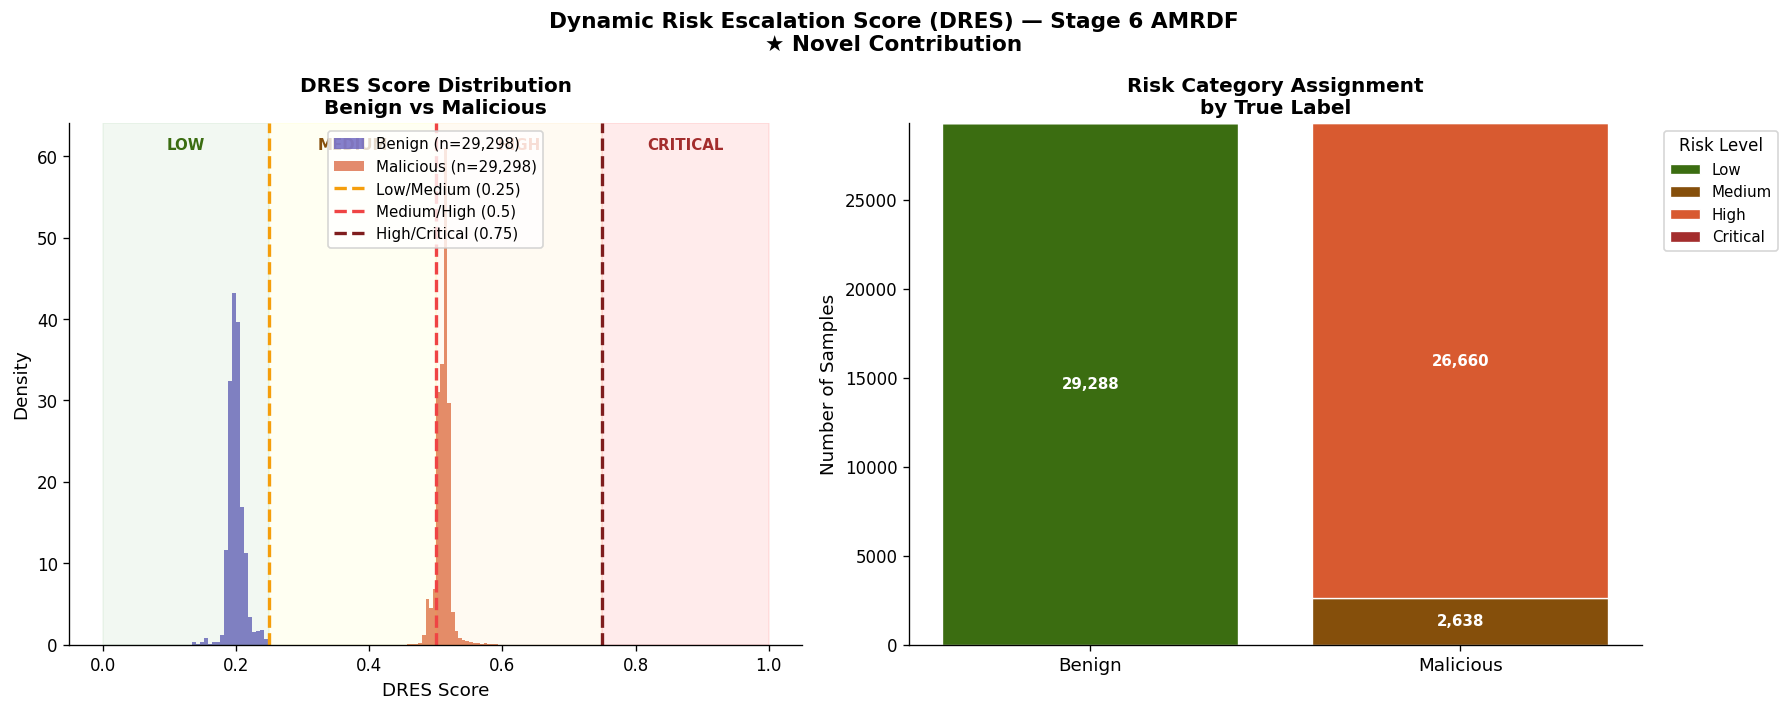

Saved: dres_distribution.png


In [10]:
 #── CELL 8 ──────────────────────────────────────────────────────
# PLOT 1 — DRES Distribution (main result figure)
risk_colors = {'Low':'#3B6D11','Medium':'#854F0B',
               'High':'#D85A30','Critical':'#A32D2D'}
 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
 
# Panel 1 — DRES score histogram by true label with threshold lines
benign_dres    = results_df[results_df['true_class']==0]['dres_score']
malicious_dres = results_df[results_df['true_class']==1]['dres_score']
 
axes[0].hist(benign_dres,    bins=60, alpha=0.70, color='#534AB7',
             label=f'Benign (n={len(benign_dres):,})',
             density=True, edgecolor='none')
axes[0].hist(malicious_dres, bins=60, alpha=0.70, color='#D85A30',
             label=f'Malicious (n={len(malicious_dres):,})',
             density=True, edgecolor='none')
 
# Threshold lines
thresh_data = [(0.25,'#F59E0B','Low/Medium'),
               (0.50,'#EF4444','Medium/High'),
               (0.75,'#7F1D1D','High/Critical')]
for thresh, color, label in thresh_data:
    axes[0].axvline(thresh, color=color, linestyle='--',
                    lw=2, label=f'{label} ({thresh})')
 
# Risk zone shading
axes[0].axvspan(0,    0.25, alpha=0.05, color='green')
axes[0].axvspan(0.25, 0.50, alpha=0.05, color='yellow')
axes[0].axvspan(0.50, 0.75, alpha=0.05, color='orange')
axes[0].axvspan(0.75, 1.00, alpha=0.08, color='red')
 
axes[0].text(0.125, axes[0].get_ylim()[1]*0.95 if axes[0].get_ylim()[1] > 0 else 1,
             'LOW',      ha='center', fontsize=9, color='#3B6D11', fontweight='bold')
axes[0].text(0.375, axes[0].get_ylim()[1]*0.95 if axes[0].get_ylim()[1] > 0 else 1,
             'MEDIUM',   ha='center', fontsize=9, color='#854F0B', fontweight='bold')
axes[0].text(0.625, axes[0].get_ylim()[1]*0.95 if axes[0].get_ylim()[1] > 0 else 1,
             'HIGH',     ha='center', fontsize=9, color='#D85A30', fontweight='bold')
axes[0].text(0.875, axes[0].get_ylim()[1]*0.95 if axes[0].get_ylim()[1] > 0 else 1,
             'CRITICAL', ha='center', fontsize=9, color='#A32D2D', fontweight='bold')
 
axes[0].set_xlabel('DRES Score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('DRES Score Distribution\nBenign vs Malicious',
                  fontweight='bold')
axes[0].legend(fontsize=9, loc='upper center')
 
# Panel 2 — Stacked bar: risk tiers by true label
x = np.arange(2)
bottoms = np.zeros(2)
for risk in risk_order:
    b_count = len(results_df[(results_df['risk_category']==risk) &
                              (results_df['true_class']==0)])
    m_count = len(results_df[(results_df['risk_category']==risk) &
                              (results_df['true_class']==1)])
    vals = [b_count, m_count]
    bars = axes[1].bar(x, vals, bottom=bottoms,
                       color=risk_colors[risk], label=risk,
                       edgecolor='white', linewidth=0.8)
    for xi, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 100:
            axes[1].text(xi, b + v/2, f'{v:,}',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottoms += vals
 
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Benign', 'Malicious'], fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].set_title('Risk Category Assignment\nby True Label',
                  fontweight='bold')
axes[1].legend(title='Risk Level', fontsize=9,
               bbox_to_anchor=(1.02, 1), loc='upper left')
 
plt.suptitle('Dynamic Risk Escalation Score (DRES) — Stage 6 AMRDF\n'
             '★ Novel Contribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'dres_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dres_distribution.png")

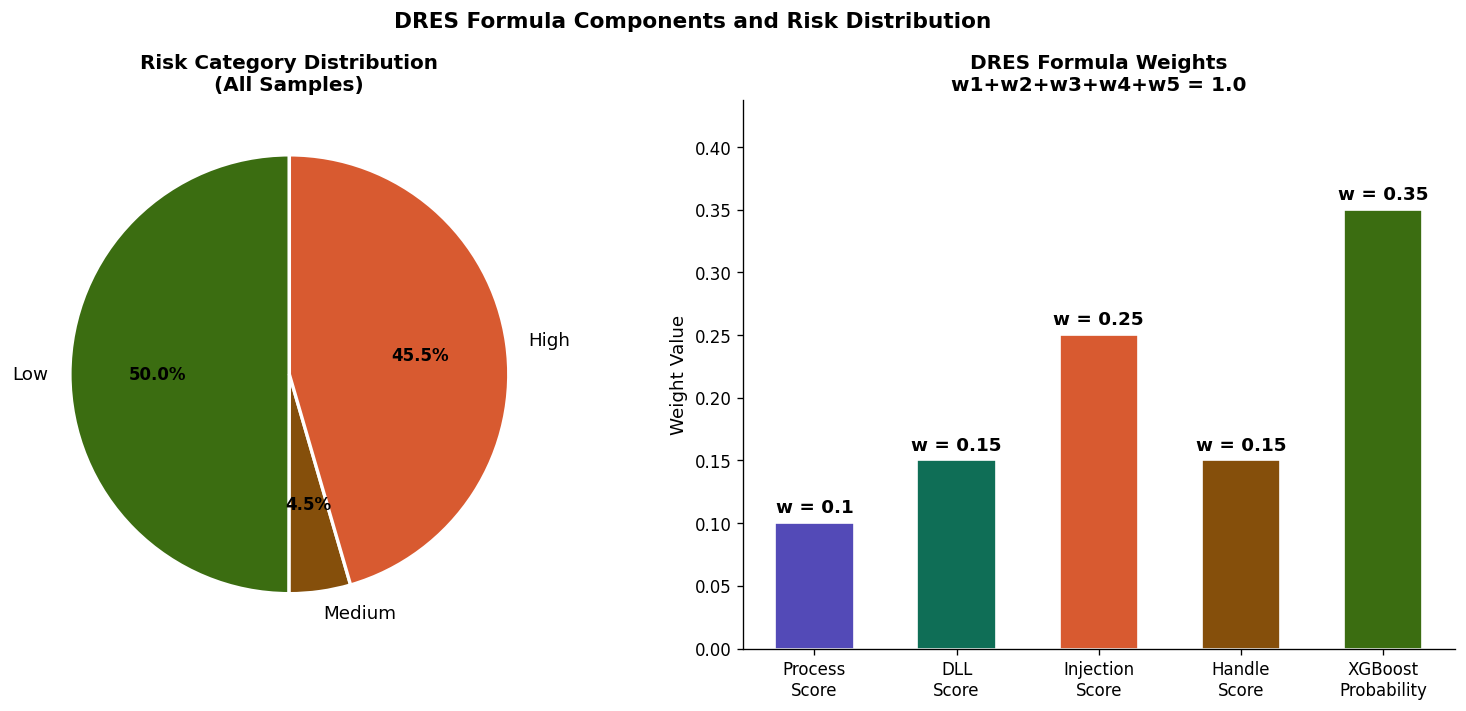

Saved: dres_weights_pie.png


In [11]:
# ── CELL 9 ──────────────────────────────────────────────────────
# PLOT 2 — DRES pie chart + component weight chart
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
 
# Pie chart of risk category counts
risk_counts = results_df['risk_category'].value_counts()
pie_order   = [r for r in risk_order if r in risk_counts.index]
pie_values  = [risk_counts[r] for r in pie_order]
pie_colors  = [risk_colors[r] for r in pie_order]
 
wedges, texts, autotexts = axes[0].pie(
    pie_values, labels=pie_order, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2},
    textprops={'fontsize':11})
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(10)
axes[0].set_title('Risk Category Distribution\n(All Samples)',
                  fontweight='bold')
 
# DRES weight bar chart (formula visualization)
components = ['Process\nScore', 'DLL\nScore',
              'Injection\nScore', 'Handle\nScore',
              'XGBoost\nProbability']
weights    = [W1, W2, W3, W4, W5]
colors_w   = ['#534AB7','#0F6E56','#D85A30','#854F0B','#3B6D11']
 
bars = axes[1].bar(components, weights, color=colors_w,
                   edgecolor='white', width=0.55)
for bar, w in zip(bars, weights):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'w = {w}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
 
axes[1].set_ylabel('Weight Value', fontsize=11)
axes[1].set_ylim([0, max(weights) * 1.25])
axes[1].set_title('DRES Formula Weights\n'
                  f'w1+w2+w3+w4+w5 = {sum(weights):.1f}',
                  fontweight='bold')
 
plt.suptitle('DRES Formula Components and Risk Distribution',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'dres_weights_pie.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dres_weights_pie.png")

In [12]:
# ── CELL 10 ──────────────────────────────────────────────────────
# Save DRES results
results_path = os.path.join(REPORT_DIR, 'dres_results.csv')
results_df.to_csv(results_path, index=False)
 
print(f"Saved: dres_results.csv — {len(results_df):,} samples")
print(f"\nDRES Formula Summary:")
print(f"  DRES = {W1}×process + {W2}×dll + {W3}×injection")
print(f"       + {W4}×handle + {W5}×xgboost_prob")
print(f"\nRisk thresholds:")
print(f"  Low      : DRES < 0.25")
print(f"  Medium   : 0.25 ≤ DRES < 0.50")
print(f"  High     : 0.50 ≤ DRES < 0.75")
print(f"  Critical : DRES ≥ 0.75")
print("\nNotebook 08 complete — proceed to 09_visualizations.ipynb")
 

Saved: dres_results.csv — 58,596 samples

DRES Formula Summary:
  DRES = 0.1×process + 0.15×dll + 0.25×injection
       + 0.15×handle + 0.35×xgboost_prob

Risk thresholds:
  Low      : DRES < 0.25
  Medium   : 0.25 ≤ DRES < 0.50
  High     : 0.50 ≤ DRES < 0.75
  Critical : DRES ≥ 0.75

Notebook 08 complete — proceed to 09_visualizations.ipynb
